# 阶段 1：训练 Bigram 语言模型

这个 Notebook 调用项目中的 `llm_learning.bigram` 库，逐步走完一个完整训练循环。正式训练入口保留在 `python -m llm_learning.bigram.train`。

```text
Dataset
→ DataLoader
→ Forward
→ Loss
→ Backward
→ Optimizer step
→ Validation
→ Checkpoint
→ Generation
```

## 1. 导入阶段 1 的实现

Notebook 负责组织实验和展示中间结果。Tokenizer、Dataset、模型、checkpoint 和评估函数统一来自 `llm_learning.bigram` 库。

In [1]:
from pathlib import Path
import os

import torch

# 切换到仓库根目录，统一数据与输出路径。
project_root = Path.cwd()
if not (project_root / "pyproject.toml").is_file():
    project_root = project_root.parent
os.chdir(project_root)

from llm_learning.bigram.checkpoint import load_checkpoint, save_checkpoint
from llm_learning.bigram.data import (
    NextTokenDataset,
    download_tiny_shakespeare,
    split_token_ids,
)
from llm_learning.bigram.model import BigramLanguageModel
from llm_learning.bigram.tokenizer import CharacterTokenizer
from llm_learning.bigram.train import (
    evaluate,
    make_evaluation_loader,
    make_loader,
    seed_everything,
)

# 固定随机状态，并优先使用可用的 GPU。
seed = 1337
seed_everything(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 2. 下载并读取 Tiny Shakespeare

数据文件固定来自 Karpathy char-rnn commit `6f9487a`。数据函数负责下载或复用本地文件，本 Notebook 只关注字符语言模型的训练流程。

In [2]:
# 下载固定数据，并读取完整训练文本。
data_path = Path("data/tinyshakespeare/input.txt")
download_tiny_shakespeare(data_path)
text = data_path.read_text(encoding="utf-8")

print("characters:", len(text))
print("first 200 characters:\n")
print(text[:200])

characters: 1115394
first 200 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## 3. 构建字符级 tokenizer

字符 tokenizer 先统计语料中的全部字符，再按排序后的字符表分配 ID。`encode()` 返回 token ID 列表，`decode()` 将 ID 还原成文本。`vocab_size` 决定模型 logits 的最后一维。

当前样本定长且没有 padding，Bigram 也没有 attention 层，因此 tokenizer 只返回 token ID，不生成 `attention_mask`。

In [3]:
# 从语料字符构建词表，并验证编码可以还原。
tokenizer = CharacterTokenizer.from_text(text)
sample_text = "First Citizen:\n"
sample_ids = tokenizer.encode(sample_text)
decoded_sample = tokenizer.decode(sample_ids)

print("vocab size:", tokenizer.vocab_size)
print("vocabulary:", repr("".join(tokenizer.characters)))
print("sample text:", repr(sample_text))
print("sample IDs:", sample_ids)
print("decoded:", repr(decoded_sample))
print("round trip:", decoded_sample == sample_text)

vocab size: 65
vocabulary: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
sample text: 'First Citizen:\n'
sample IDs: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0]
decoded: 'First Citizen:\n'
round trip: True


## 4. 顺序切分 train 和 validation

完整文本先编码为 token ID。`split_token_ids` 返回 `train_ids`、`validation_ids` 和切分位置。前 90% 进入 train，后 10% 进入 validation。切分时保持文本顺序，validation 数据不参与参数更新。

In [4]:
# 先切分 token 流，再分别创建训练和验证样本。
all_token_ids = tokenizer.encode(text)
train_ids, validation_ids, split_index = split_token_ids(
    all_token_ids, train_fraction=0.9
)

print("total tokens:", len(all_token_ids))
print("split index:", split_index)
print("train tokens:", len(train_ids))
print("validation tokens:", len(validation_ids))
print("train fraction:", len(train_ids) / len(all_token_ids))

total tokens: 1115394
split index: 1003854
train tokens: 1003854
validation tokens: 111540
train fraction: 0.8999994620734916


## 5. Dataset 构造 next-token 样本

`NextTokenDataset` 保存一条完整 token Tensor，并用滑动窗口提供训练样本。记窗口长度为 $T$，`dataset[index]` 返回一对属于 $\mathbb{N}^{T}$ 的 Tensor：inputs 从 index 开始，targets 从 index 的下一个 token 开始。

样本数为 `token 数量 - block_size`。相邻样本会重叠；记批量大小为 $B$，DataLoader 随后将多个长度为 $T$ 的样本组成 $\mathbf{X},\mathbf{Y}\in\mathbb{N}^{B\times T}$。

In [5]:
# 相邻窗口分别构成输入和 next-token 标签。
display_dataset = NextTokenDataset(train_ids, block_size=8)
display_inputs, display_targets = display_dataset[0]

print("input IDs:", display_inputs.tolist())
print("target IDs:", display_targets.tolist())
print("input text:", repr(tokenizer.decode(display_inputs.tolist())))
print("target text:", repr(tokenizer.decode(display_targets.tolist())))
print("input shape:", tuple(display_inputs.shape))
print("target shape:", tuple(display_targets.shape))

input IDs: [18, 47, 56, 57, 58, 1, 15, 47]
target IDs: [47, 56, 57, 58, 1, 15, 47, 58]
input text: 'First Ci'
target text: 'irst Cit'
input shape: (8,)
target shape: (8,)


每个输入位置对应右侧紧邻的字符。长度为 8 的样本会产生 8 个 next-token 预测目标。

## 6. DataLoader 组成 batch

当前只有一个 `train_dataset`，其中保存了从训练文本切出的全部滑动窗口样本。DataLoader 不会创建或划分新的 Dataset。

`make_loader()` 返回 DataLoader 对象。它保存 Dataset 的引用和取样规则，本身不代表某个 batch。取数据的过程如下：

```text
make_loader() → DataLoader → iter(loader) → next(iterator) → 两个 batch Tensor
```

`len(train_loader)` 表示遍历全部训练样本一次需要多少个 batch。固定 seed 让完整训练重新运行时得到相同的打乱过程。

`shuffle=True` 打乱的是样本索引。样本内部的 token 顺序保持不变。shuffle 的作用取决于训练预算：

- 训练不足一个 epoch 时，shuffle 会让抽到的样本来自文本中的不同位置。关闭 shuffle 只会依次训练文本开头。当前短训练属于这种情况。
- 完整训练多个 epoch 时，两种方式最终都会看到全部样本。shuffle 会减少相邻 batch 内容过于相似的情况，通常有利于训练前期的参数更新，但不保证获得更低的最终 loss。

In [6]:
# DataLoader 将多个样本堆叠为形状 [B,T] 的 batch。
block_size = 32
batch_size = 32
train_dataset = NextTokenDataset(train_ids, block_size)
validation_dataset = NextTokenDataset(validation_ids, block_size)
train_loader = make_loader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    seed=seed,
    device=device,
)
batch_inputs, batch_targets = next(iter(train_loader))

print("training samples:", len(train_dataset))
print("batches per epoch:", len(train_loader))
print("batch input shape:", tuple(batch_inputs.shape))
print("batch target shape:", tuple(batch_targets.shape))
print("first input:", repr(tokenizer.decode(batch_inputs[0].tolist())))
print("first target:", repr(tokenizer.decode(batch_targets[0].tolist())))

training samples: 1003822
batches per epoch: 31369
batch input shape: (32, 32)
batch target shape: (32, 32)
first input: 'uld thou wert so too!\n\nLUCIO:\nWe'
first target: 'ld thou wert so too!\n\nLUCIO:\nWel'


`next(iter(train_loader))` 只返回一个 batch，因此这里只看到两个形状为 $32\times32$ 的 Tensor。DataLoader 保存 Dataset 和采样规则，迭代器会按照这些规则继续生成后续 batch。

由于开启了 shuffle，`batch_inputs[0]` 是随机排列后当前 batch 的第一条样本，不代表原始文本的第一句话。Dataset 按 32 个字符截取窗口，也不识别句子边界。

## 7. Bigram 模型执行 forward

`BigramLanguageModel` 接收词表大小 $V$，并创建随机初始化的 `nn.Embedding`。其权重矩阵满足 $\mathbf{W}\in\mathbb{R}^{V\times V}$；第 $i$ 行表示当前 token ID 为 $i$ 时，对 $V$ 个候选 token 给出的 logits。模型和 batch 通过 `.to(device)` 放到同一设备。

调用 `model(inputs, targets)` 时，`nn.Module.__call__()` 会执行模型的 `forward()`，并返回 `(logits, loss)`。

In [7]:
seed_everything(seed)
# 创建随机初始化的模型，并让模型和 batch 位于同一设备。
model = BigramLanguageModel(tokenizer.vocab_size).to(device)
batch_inputs = batch_inputs.to(device)
batch_targets = batch_targets.to(device)
# model(...) 经 nn.Module.__call__() 进入 forward()。
logits, initial_loss = model(batch_inputs, batch_targets)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print("parameters:", parameter_count)
print("input shape:", tuple(batch_inputs.shape))
print("logits shape:", tuple(logits.shape))
print("loss shape:", tuple(initial_loss.shape))
print("initial loss:", initial_loss.item())

BigramLanguageModel(
  (token_embedding_table): Embedding(65, 65)
)
parameters: 4225
input shape: (32, 32)
logits shape: (32, 32, 65)
loss shape: ()
initial loss: 4.738241195678711


输入 token IDs 满足 $\mathbf{X}\in\mathbb{N}^{B\times T}$，forward 输出 logits $\mathbf{Z}\in\mathbb{R}^{B\times T\times V}$。Cross entropy 将 $BT$ 个位置视为 $BT$ 个字符分类任务，并返回平均 loss。`loss.shape == []` 表示它是保存一个数值的零维 Tensor。

forward 在计算 logits 和 loss 的同时建立 autograd 计算图。`initial_loss.grad_fn` 是这张图的反向计算入口。沿 `next_functions` 向下遍历，可以看到 loss 与 embedding 参数之间的运算连接。

In [8]:
# 从标量 loss 的 grad_fn 递归打印反向依赖。
def print_autograd_graph(
    node,
    depth=0,
    visited=None,
):
    if node is None:
        return

    if visited is None:
        visited = set()

    indentation = "    " * depth
    node_name = type(node).__name__
    print(f"{indentation}{node_name}")

    if id(node) in visited:
        return

    visited.add(id(node))

    for next_node, _ in node.next_functions:
        print_autograd_graph(
            next_node,
            depth=depth + 1,
            visited=visited,
        )


print_autograd_graph(initial_loss.grad_fn)

NllLossBackward0
    LogSoftmaxBackward0
        ViewBackward0
            EmbeddingBackward0
                AccumulateGrad


输出从 loss 节点开始，逐步展开到模型参数。这个方向与 forward 的计算方向相反。节点含义如下：

- `EmbeddingBackward0` 对应 embedding 查表。
- `ViewBackward0` 对应 logits 的 reshape。
- `LogSoftmaxBackward0` 和 `NllLossBackward0` 共同对应 cross entropy。
- `AccumulateGrad` 指向需要训练的 embedding 参数。

计算图保存运算之间的连接关系。标量 loss 保存一个数值，backward 会沿这张图计算形状为 $65\times65$ 的参数梯度。

## 8. 执行 backward 与参数更新

第 7 节的 forward 已经得到 `initial_loss` 并建立计算图。本节从这张图执行 backward，再更新参数：

1. optimizer 保存模型参数的引用，并规定参数更新方法和学习率。
2. 参数快照记录更新前的权重，供更新后比较。`detach()` 切断计算图，`clone()` 复制独立数据。
3. `zero_grad(set_to_none=True)` 清除上一步保存在参数 `.grad` 中的梯度。PyTorch 默认会累加梯度。
4. `initial_loss.backward()` 沿第 7 节建立的计算图求导，并将结果写入每个参数的 `.grad`。
5. `optimizer.step()` 根据 `.grad` 和学习率直接修改模型参数。它不会再次执行 forward。

`embedding_weight` 与 `model.token_embedding_table.weight` 指向同一个 Parameter。optimizer 也保存这份 Parameter 的引用，因此 backward 和 step 修改的都是模型中的原始参数。

In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-2,
)
# 该变量是模型参数的引用；clone() 才创建独立快照。
embedding_weight = model.token_embedding_table.weight
weight_before = embedding_weight.detach().clone()

optimizer.zero_grad(set_to_none=True)
print("gradient before backward:", embedding_weight.grad)

print("loss before update:", initial_loss.item())
initial_loss.backward()
gradient = embedding_weight.grad
gradient_norm = gradient.norm().item()
print("gradient shape:", tuple(gradient.shape))
print("gradient norm:", gradient_norm)

optimizer.step()

weight_after = embedding_weight.detach()
update_norm = (weight_after - weight_before).norm().item()

# 这里只比较更新后的 loss，无需建立新的计算图。
with torch.no_grad():
    _, loss_after_update = model(
        batch_inputs,
        batch_targets,
    )

print("parameter update norm:", update_norm)
print("loss after update:", loss_after_update.item())

gradient before backward: None
loss before update: 4.738241195678711
gradient shape: (65, 65)
gradient norm: 0.0897148922085762
parameter update norm: 0.5869828462600708
loss after update: 4.7213897705078125


本例中的 embedding 权重满足 $\mathbf{W}\in\mathbb{R}^{V\times V}$，每个参数元素都有一个偏导数，因此当前参数梯度的形状也是 $65\times65$。`AccumulateGrad` 持有原始 Parameter 的引用，backward 最终将结果写入它的 `.grad`。

`gradient norm` 概括 backward 产生的梯度大小，`update norm` 概括 optimizer 实际造成的参数变化。`torch.no_grad()` 阻止新计算图的建立，`optimizer.zero_grad()` 清除参数中已有的 `.grad`。

再次使用同一个 batch 执行 forward 后，loss 下降说明这一步更新改善了当前 batch 的预测。一次更新不能保证 validation loss 同步下降。

## 9. 在重复训练中加入定期评估

训练循环中的 forward、backward 和 optimizer step 已在第 7～8 节完成。本节重复这些操作 300 次，只新增四项训练管理逻辑：

1. `make_evaluation_loader` 分别固定 320 个训练样本和 320 个验证样本。
2. `evaluate` 关闭梯度，计算固定样本的平均 loss，然后恢复训练状态。
3. `step == 1 or step % 100 == 0` 规定执行评估的时机。
4. `history` 保存每次评估的 step、train loss 和 validation loss。

train loss 反映模型对固定训练样本的拟合程度，validation loss 反映模型对固定验证样本的表现。

In [10]:
# 重建模型和 optimizer，让短训练从固定初始参数开始。
seed_everything(seed)
model = BigramLanguageModel(tokenizer.vocab_size).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-2,
)

# 训练 batch 持续打乱；300 steps 不会用完一个 epoch。
train_loader = make_loader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    device=device,
    seed=seed,
)

# 当前训练 batch 每步变化，其 loss 用于 backward，无法直接横向比较。
# 固定训练子集用于计算参数更新后、不同 step 可比较的 train loss。
# 验证子集同样只选择一次，后续评估始终复用。
evaluation_batches = 10
train_eval_loader = make_evaluation_loader(
    dataset=train_dataset,
    batch_size=batch_size,
    batches=evaluation_batches,
    seed=seed + 1,
    device=device,
)
validation_loader = make_evaluation_loader(
    dataset=validation_dataset,
    batch_size=batch_size,
    batches=evaluation_batches,
    seed=seed + 2,
    device=device,
)

max_steps = 300
train_iterator = iter(train_loader)
history = []
sample_coverage = max_steps * batch_size / len(train_dataset)

print("training steps:", max_steps)
print("fraction of one epoch: {:.2%}".format(sample_coverage))

# 每个 step 重复第 8 节的一次参数更新。
for step in range(1, max_steps + 1):
    inputs, targets = next(train_iterator)
    inputs = inputs.to(device)
    targets = targets.to(device)

    optimizer.zero_grad(set_to_none=True)
    _, loss = model(inputs, targets)
    loss.backward()
    optimizer.step()

    # 只在指定 step 使用固定样本评估，不更新参数。
    if step == 1 or step % 100 == 0:
        train_loss = evaluate(
            model=model,
            loader=train_eval_loader,
            batches=evaluation_batches,
            device=device,
        )
        validation_loss = evaluate(
            model=model,
            loader=validation_loader,
            batches=evaluation_batches,
            device=device,
        )

        # 将同一时刻的训练损失和验证损失保存到 history。
        metric = {
            "step": step,
            "train_loss": train_loss,
            "validation_loss": validation_loss,
        }
        history.append(metric)
        print(metric)

training steps: 300
fraction of one epoch: 0.96%


{'step': 1, 'train_loss': 4.701589298248291, 'validation_loss': 4.706446743011474}


{'step': 100, 'train_loss': 3.578174519538879, 'validation_loss': 3.5966569423675536}


{'step': 200, 'train_loss': 2.965879225730896, 'validation_loss': 2.989029383659363}


{'step': 300, 'train_loss': 2.689296841621399, 'validation_loss': 2.7144831895828245}


Train loss 和 validation loss 同时下降，说明模型学到的字符转移规律在验证文本上同样有效。Bigram 只能读取当前字符。训练一段时间后，loss 的下降速度会逐渐变慢。

## 10. 保存并恢复 checkpoint

Checkpoint 保存模型参数、optimizer 状态、step、配置、tokenizer、指标历史以及 CPU/CUDA 随机数状态。它是训练状态快照，保存后可以继续训练。正式入口会周期性保存，Notebook 在短训练结束后保存一次。

恢复测试创建新模型和新 optimizer，加载 checkpoint 后比较恢复前后的 logits。

In [11]:
# 保存当前 step 对应的完整训练状态。
checkpoint_path = Path("checkpoints/bigram_notebook/latest.pt")
save_checkpoint(
    path=checkpoint_path,
    model=model,
    optimizer=optimizer,
    step=step,
    config={"block_size": block_size, "batch_size": batch_size},
    tokenizer=tokenizer.to_dict(),
    history=history,
)

# 先创建空白训练状态，再用 checkpoint 覆盖。
restored_model = BigramLanguageModel(tokenizer.vocab_size).to(device)
restored_optimizer = torch.optim.AdamW(
    restored_model.parameters(),
    lr=1e-2,
)
checkpoint = load_checkpoint(
    path=checkpoint_path,
    model=restored_model,
    optimizer=restored_optimizer,
    device=device,
)

comparison_input = batch_inputs[:1]
with torch.no_grad():
    original_logits, _ = model(comparison_input)
    restored_logits, _ = restored_model(comparison_input)

print("restored step:", checkpoint["step"])
print("logits match:", torch.equal(original_logits, restored_logits))
print("checkpoint path:", checkpoint_path)

restored step: 300
logits match: True
checkpoint path: checkpoints/bigram_notebook/latest.pt


`logits match: True` 表示新模型成功恢复了相同参数和 forward 结果。

## 11. 生成文本

生成从一个换行 token 开始。模型根据当前字符的 logits 采样下一个字符，再把新字符接回序列。`max_new_tokens=300` 会追加 300 个 token，返回结果还包含 1 个起始 token，因此共有 301 个 token。

In [12]:
generation_device = "cuda" if device.type == "cuda" else "cpu"
# 使用独立且可复现的生成随机序列，不推进训练使用的随机状态。
generation_generator = torch.Generator(
    device=generation_device,
)
generation_generator.manual_seed(seed + 3)
# 从一个换行 token 开始自回归生成。
start_token_id = tokenizer.encode("\n")[0]
start_token = torch.tensor(
    [[start_token_id]],
    device=device,
)
generated_tokens = restored_model.generate(
    start_token,
    max_new_tokens=300,
    generator=generation_generator,
)
generated_ids = generated_tokens[0].tolist()
generated_text = tokenizer.decode(generated_ids)

output_path = Path("outputs/bigram_notebook/generated.txt")
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(generated_text, encoding="utf-8")
print(generated_text)


ThabotN&ou :
Uvxd fithomiMAUAn! 3Shqiefthes mzerPaima!$&jKI ng! rNGd at wh ENAOve n.
LMld.
Wh,DMalsBHdYwarFCUjKISP Mf thanguADWWis ufSolsorureaRIszy te nopeUCOp yhaXYoisUNd'theaHa eddutr HE: A KIIJUge I d mce saP, f:g L&Gl w ak n thalitha ETimbr kersof RWVxpeirlzd we warulveve iNGre;
My CbOby aske b


Bigram 只能利用一个当前字符。生成结果通常具有局部拼写、空格和标点规律，长程语义仍然混乱。

## 12. Loss 曲线与故障观察

左图使用第 9 节的 `history` 展示正常训练过程。右图数据来自已执行的固定故障实验，对比正常学习率和过大学习率的 validation loss。

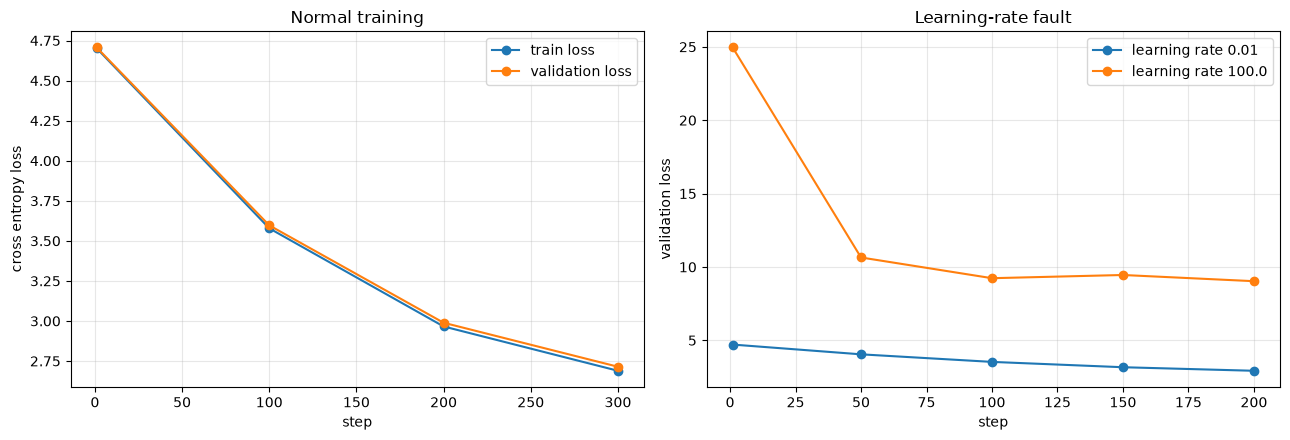

In [13]:
import matplotlib.pyplot as plt

steps = [metric["step"] for metric in history]
train_losses = [metric["train_loss"] for metric in history]
validation_losses = [
    metric["validation_loss"]
    for metric in history
]

# 以下数值来自 outputs/bigram_fault 中的固定故障实验记录。
fault_steps = [1, 50, 100, 150, 200]
control_validation_losses = [
    4.7116,
    4.0465,
    3.5312,
    3.1681,
    2.9257,
]
excessive_lr_validation_losses = [
    24.9543,
    10.6459,
    9.2342,
    9.4526,
    9.0305,
]

# 左图观察正常训练，右图对比故障学习率。
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.5),
)
training_axis, fault_axis = axes

training_axis.plot(
    steps,
    train_losses,
    marker="o",
    label="train loss",
)
training_axis.plot(
    steps,
    validation_losses,
    marker="o",
    label="validation loss",
)
training_axis.set_xlabel("step")
training_axis.set_ylabel("cross entropy loss")
training_axis.set_title("Normal training")
training_axis.grid(alpha=0.3)
training_axis.legend()

fault_axis.plot(
    fault_steps,
    control_validation_losses,
    marker="o",
    label="learning rate 0.01",
)
fault_axis.plot(
    fault_steps,
    excessive_lr_validation_losses,
    marker="o",
    label="learning rate 100.0",
)
fault_axis.set_xlabel("step")
fault_axis.set_ylabel("validation loss")
fault_axis.set_title("Learning-rate fault")
fault_axis.grid(alpha=0.3)
fault_axis.legend()

figure.tight_layout()
plt.show()

正常训练的两条曲线同时下降，且 train loss 与 validation loss 的差距很小，当前没有明显过拟合。明显过拟合通常表现为 train loss 继续下降，而 validation loss 停止下降或开始上升。

固定故障实验只改变学习率。Control 使用 $0.01$，故障组使用 $100.0$。200 steps 后的结果如下：

| Run | Step 1 validation loss | Step 200 validation loss |
| --- | ---: | ---: |
| Control | 4.7116 | 2.9257 |
| Learning rate 100.0 | 24.9543 | 9.0305 |

过大的学习率造成明显的 loss 恶化和重复生成。完整记录保存在 `docs/stages/01_bigram/FAULT_OBSERVATION.md`，复现命令为 `python -m llm_learning.bigram.fault_experiment --steps 200`。

## 13. 阶段 1 验收

### 1. 完整训练循环包含哪些步骤？

> Dataset、DataLoader、forward、loss、清空梯度、backward、optimizer step、validation 和 checkpoint。

### 2. Bigram 模型学到了什么？

> 它学习当前字符到下一个字符的条件分布，每个预测只依赖一个当前字符。

### 3. validation 为什么不能更新参数？

> Validation 用于估计模型对保留数据的表现。参数更新会把验证数据引入训练过程，破坏独立评估。

### 4. checkpoint 恢复训练需要哪些核心状态？

> 模型参数、optimizer 状态、当前 step、训练配置、tokenizer、指标历史和随机数状态。

### 5. 本阶段的正式验收标准

> 能够从空项目编写并运行完整训练循环，并能逐步说明每一环的数据输入、输出和作用。